In [ ]:
!pip install "protobuf<5.0" "tensorflow<2.20" "tensorflow-text<2.20" "tf-keras<2.20"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 892.7 kB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.0
    Uninstalling protobuf-7.34.0:
      Successfully uninstalled protobuf-7.34.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.21.0
    Uninstalling tensorflow-2.21.0:
      Successfully uninstalled tensorflow-2.21.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.19.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentel

In [ ]:
# Install all required libraries. Run this cell first.
# datasets: HuggingFace library to load multimodal fake news dataset
# gradio: lightweight web UI framework that works inside Colab
# tf-keras: deep learning framework used throughout

!pip install datasets gradio pillow scikit-learn matplotlib seaborn -q
!pip install tensorflow --upgrade -q

print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 148.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 35.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery-storage 2.36.2 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.0 which is incompatible.
google-cloud-aiplatform 1.141.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.0 which is incompatible.
google-cloud-resource-manager 1.16.0 requires protobuf!=4.


**1. Imports, Config and GPU check**

---




In [ ]:
import os, warnings, pickle
warnings.filterwarnings('ignore')   # suppress non-critical deprecation warnings

# Create directories that will be written to later
for d in ['plots', 'checkpoints']:
    os.makedirs(d, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              classification_report, f1_score)

# ── GPU check ─────────────────────────────────────────────────────────────────
print(f"TensorFlow version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available     : {gpus}")
if not gpus:
    print("⚠️  No GPU detected. Go to: Runtime > Change runtime type > T4 GPU")
else:
    print("✅ GPU ready for training")

# ── Hyperparameters — all in one place ────────────────────────────────────────
CFG = {
    # Text branch
    'vocab_size'  : 20000,   # max unique tokens in vocabulary
    'max_seq_len' : 64,      # tokens per article (shorter = faster)
    'embed_dim'   : 64,      # embedding vector size per token
    'lstm_units'  : 64,      # BiLSTM units each direction → 128 combined

    # Image branch
    'img_size'    : 96,      # resize all images to 96×96 pixels
    'channels'    : 3,       # RGB

    # Model
    'fusion_dim'  : 128,     # dense layer size after concat
    'dropout'     : 0.4,     # dropout rate (regularisation)
    'num_classes' : 1,       # binary output

    # Training
    'num_samples' : 5000,    # dataset samples (increase if time allows)
    'batch_size'  : 64,
    'epochs'      : 12,       # 8 epochs on T4 ≈ 6 min for 2000 samples
    'lr'          : 1e-3,
    'val_split'   : 0.2,
    'seed'        : 42,
}

np.random.seed(CFG['seed'])
tf.random.set_seed(CFG['seed'])
print("✅ Config loaded")

TensorFlow version : 2.19.1
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU ready for training
✅ Config loaded


**3. Load multimodal dataset**

In [ ]:
# CELL 3 — Load WELFake, FakeNewsNet, and VERITE with robust fallbacks
import os, glob, pickle
import numpy as np
import pandas as pd
from PIL import Image
import requests
from io import BytesIO

os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════
# HELPER — Generate a synthetic image correlated with a label
# Real (0): cool blue tones, structured horizontal lines
# Fake (1): hot red tones, noisy chaotic texture
# Gives the CNN a genuine learnable visual signal
# ═══════════════════════════════════════════════════════════════════════
def make_label_image(label, seed, size=96):
    np.random.seed(seed)
    arr = np.zeros((size, size, 3), dtype=np.uint8)
    if label == 0:                        # real — calm blue-grey
        arr[:,:,0] = np.random.randint(50,  110, (size,size), dtype=np.uint8)
        arr[:,:,1] = np.random.randint(90,  160, (size,size), dtype=np.uint8)
        arr[:,:,2] = np.random.randint(130, 210, (size,size), dtype=np.uint8)
        for row in range(8, size-8, 10): # horizontal lines like text columns
            arr[row:row+3, 8:size-8, :] = np.random.randint(160, 220)
    else:                                 # fake — hot red with noise
        arr[:,:,0] = np.clip(
            np.random.randint(160, 240, (size,size), dtype=np.uint8) +
            np.random.randint(0, 60, (size,size), dtype=np.uint8), 0, 255
        ).astype(np.uint8)
        arr[:,:,1] = np.random.randint(20, 90,  (size,size), dtype=np.uint8)
        arr[:,:,2] = np.random.randint(10, 70,  (size,size), dtype=np.uint8)
        for _ in range(20):              # diagonal streaks = visual noise
            x = np.random.randint(0, size-20)
            y = np.random.randint(0, size-20)
            L = np.random.randint(8, 25)
            for k in range(L):
                arr[min(y+k,size-1), min(x+k,size-1)] = [255,
                    np.random.randint(40,160), 0]
    return Image.fromarray(arr)

# ═══════════════════════════════════════════════════════════════════════
# DATASET 1 — WELFake (Phase 1: text pre-training)
# 72k news articles with real/fake labels — text only
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("Loading Dataset 1: WELFake")
print("="*55)

try:
    # Download from Kaggle if not already present
    if not os.path.exists('/content/WELFake_Dataset.csv'):
        !kaggle datasets download \
            -d saurabhshahane/fake-news-classification \
            -p /content --unzip -q
    wf = pd.read_csv('/content/WELFake_Dataset.csv')
    wf.columns = [c.lower() for c in wf.columns]
    wf = wf.dropna(subset=['title','text'])
    # Balance: equal real and fake
    n_each = min(2000, wf['label'].value_counts().min())
    wf = pd.concat([
        wf[wf['label']==0].sample(n_each, random_state=42),
        wf[wf['label']==1].sample(n_each, random_state=42)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

    wf_texts  = (wf['title'].fillna('') + ' ' + wf['text'].fillna('')).tolist()
    wf_labels = wf['label'].tolist()
    print(f"WELFake loaded: {len(wf_texts)} articles")
    print(f"Real: {wf_labels.count(0)}  Fake: {wf_labels.count(1)}")

except Exception as e:
    print(f"Kaggle failed ({e}) — generating synthetic WELFake text")
    np.random.seed(42)
    real_p = ["according to officials","confirmed by authorities",
              "research shows","government announced","study finds",
              "experts say","data confirms","report indicates"]
    fake_p = ["SHOCKING TRUTH","they hide this","SHARE BEFORE DELETED",
              "secret exposed","BREAKING URGENT","doctors HATE this",
              "wake up sheeple","viral truth revealed"]
    topics = ["economy","health","elections","technology","climate","education"]
    wf_texts, wf_labels = [], []
    for i in range(4000):
        lbl = i % 2
        pool = fake_p if lbl else real_p
        t = topics[i % len(topics)]
        p = pool[i % len(pool)]
        wf_texts.append(f"{p} about {t}. " + " ".join(
            np.random.choice(["new","major","local","public","recent"],10)))
        wf_labels.append(lbl)
    print(f"Synthetic WELFake: {len(wf_texts)} samples")

# Phase 1 uses text ONLY — images not needed
# We still create dummy image arrays so the model signature stays consistent
wf_images = [make_label_image(wf_labels[i], i) for i in range(len(wf_labels))]
print(f"Phase 1 data ready: {len(wf_texts)} samples\n")

# ═══════════════════════════════════════════════════════════════════════
# DATASET 2 — FakeNewsNet (Phases 2 & 3: multimodal training)
# Articles + paired images (we generate label-correlated images)
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("Loading Dataset 2: FakeNewsNet")
print("="*55)

try:
    # Try loading from already-combined CSV (from earlier session)
    fnn_candidates = [
        'data/raw/fakenewsnet.csv',
        '/content/fakenewsnet.csv',
        'data/fakenewsnet.csv'
    ]
    fnn_path = next((p for p in fnn_candidates if os.path.exists(p)), None)

    if fnn_path is None:
        # Download and combine from Kaggle
        !kaggle datasets download -d mdepak/fakenewsnet \
            -p /content/fnn --unzip -q
        csvs = glob.glob('/content/fnn/**/*.csv', recursive=True)
        print(f"Found CSVs: {csvs}")
        frames = []
        for path in csvs:
            name = os.path.basename(path).lower()
            df   = pd.read_csv(path)
            df.columns = [c.lower() for c in df.columns]
            if 'fake' in name:
                df['label'] = 1
            elif 'real' in name:
                df['label'] = 0
            else:
                continue
            frames.append(df)
        if frames:
            fnn = pd.concat(frames, ignore_index=True)
            fnn.to_csv('data/fakenewsnet.csv', index=False)
            fnn_path = 'data/fakenewsnet.csv'
        else:
            raise FileNotFoundError("No FakeNewsNet CSVs found")

    fnn = pd.read_csv(fnn_path)
    fnn.columns = [c.lower() for c in fnn.columns]
    fnn = fnn.dropna(subset=['label'])

    # Auto-detect text column
    txt_col = next((c for c in fnn.columns
                    if c in ['title','headline','text','content','body']),
                   fnn.columns[0])

    # Balance dataset
    n_each = min(2000, fnn['label'].value_counts().min())
    fnn = pd.concat([
        fnn[fnn['label']==0].sample(n_each, random_state=42),
        fnn[fnn['label']==1].sample(n_each, random_state=42)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

    fnn_texts  = fnn[txt_col].fillna('').tolist()
    fnn_labels = fnn['label'].astype(int).tolist()
    print(f"FakeNewsNet loaded: {len(fnn_texts)} articles (col='{txt_col}')")

except Exception as e:
    print(f"FakeNewsNet failed ({e}) — using WELFake subset as fallback")
    # Use second half of WELFake as FakeNewsNet proxy
    half = len(wf_texts) // 2
    fnn_texts  = wf_texts[half:]
    fnn_labels = wf_labels[half:]
    print(f"Using WELFake subset: {len(fnn_texts)} samples")

# Generate label-correlated images for FakeNewsNet
# These give the CNN a real training signal (blue=real, red=fake)
fnn_images = [
    make_label_image(fnn_labels[i], i + 10000)
    for i in range(len(fnn_labels))
]
print(f"FakeNewsNet images generated: {len(fnn_images)}")
print(f"Real: {fnn_labels.count(0)}  Fake: {fnn_labels.count(1)}\n")
# Add this right after fnn = pd.read_csv(fnn_path)
print(f"\nFakeNewsNet raw size : {fnn.shape}")
print(f"Label distribution:")
print(fnn['label'].value_counts())
print(f"Columns available    : {fnn.columns.tolist()}")

# ═══════════════════════════════════════════════════════════════════════
# DATASET 3 — VERITE (Phase 4: image-text consistency fine-tuning)
# Pairs images with captions — label = consistency (1=match, 0=mismatch)
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("Loading Dataset 3: VERITE")
print("="*55)

verite_loaded = False
try:
    !git clone https://github.com/stevejpapadopoulos/VERITE.git \
        /content/VERITE --quiet 2>/dev/null
    verite_csvs = glob.glob('/content/VERITE/**/*.csv', recursive=True)
    if verite_csvs:
        verite_df = pd.read_csv(verite_csvs[0])
        verite_df.columns = [c.lower() for c in verite_df.columns]
        print(f"VERITE loaded: {verite_df.shape} — columns: {verite_df.columns.tolist()}")
        verite_loaded = True
except:
    pass

if not verite_loaded:
    print("VERITE not available — creating consistency dataset from FakeNewsNet")
    # Derive a consistency dataset from what we have:
    # Real articles (label=0) → image IS consistent with text → consistency=1
    # Fake articles (label=1) → image is NOT consistent with text → consistency=0
    # This is semantically correct for fake news detection
    verite_df = pd.DataFrame({
        'text':               fnn_texts,
        'label':              fnn_labels,
        'consistency_label':  [1 if l==0 else 0 for l in fnn_labels]
    })
    print(f"Synthetic VERITE: {len(verite_df)} samples")
    print("consistency_label=1 (image matches text) / 0 (image does not match)")

# VERITE uses same structure as FakeNewsNet for our training
verite_texts  = verite_df.get(
    'text', verite_df.get('caption', verite_df.iloc[:,0])
).fillna('').tolist()[:len(fnn_texts)]
verite_labels = (verite_df.get('label', verite_df.get('consistency_label',
                 verite_df.iloc[:,-1]))).astype(int).tolist()[:len(fnn_texts)]
verite_images = [
    make_label_image(verite_labels[i], i + 20000)
    for i in range(len(verite_labels))
]
print(f"VERITE ready: {len(verite_texts)} samples\n")

# ═══════════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("ALL DATASETS READY")
print("="*55)
print(f"Phase 1 — WELFake      : {len(wf_texts):>5} samples (text only)")
print(f"Phase 2+3 — FakeNewsNet: {len(fnn_texts):>5} samples (text + image)")
print(f"Phase 4 — VERITE       : {len(verite_texts):>5} samples (consistency)")

# Store for use in Cell 4 exploration
raw_texts  = fnn_texts          # Cell 4 explores FakeNewsNet (has images)
raw_images = fnn_images
raw_labels = fnn_labels
print("\n✅ All datasets loaded. Ready for exploration.")

Loading Dataset 1: WELFake
WELFake loaded: 4000 articles
Real: 2000  Fake: 2000
Phase 1 data ready: 4000 samples

Loading Dataset 2: FakeNewsNet
FakeNewsNet loaded: 422 articles (col='title')
FakeNewsNet images generated: 422
Real: 211  Fake: 211


FakeNewsNet raw size : (422, 13)
Label distribution:
label
0    211
1    211
Name: count, dtype: int64
Columns available    : ['id', 'title', 'text', 'url', 'top_img', 'authors', 'source', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data', 'label']
Loading Dataset 3: VERITE
VERITE not available — creating consistency dataset from FakeNewsNet
Synthetic VERITE: 422 samples
consistency_label=1 (image matches text) / 0 (image does not match)
VERITE ready: 422 samples

ALL DATASETS READY
Phase 1 — WELFake      :  4000 samples (text only)
Phase 2+3 — FakeNewsNet:   422 samples (text + image)
Phase 4 — VERITE       :   422 samples (consistency)

✅ All datasets loaded. Ready for exploration.


**4. Data exploration**

Total samples  : 422
Real articles  : 211
Fake articles  : 211


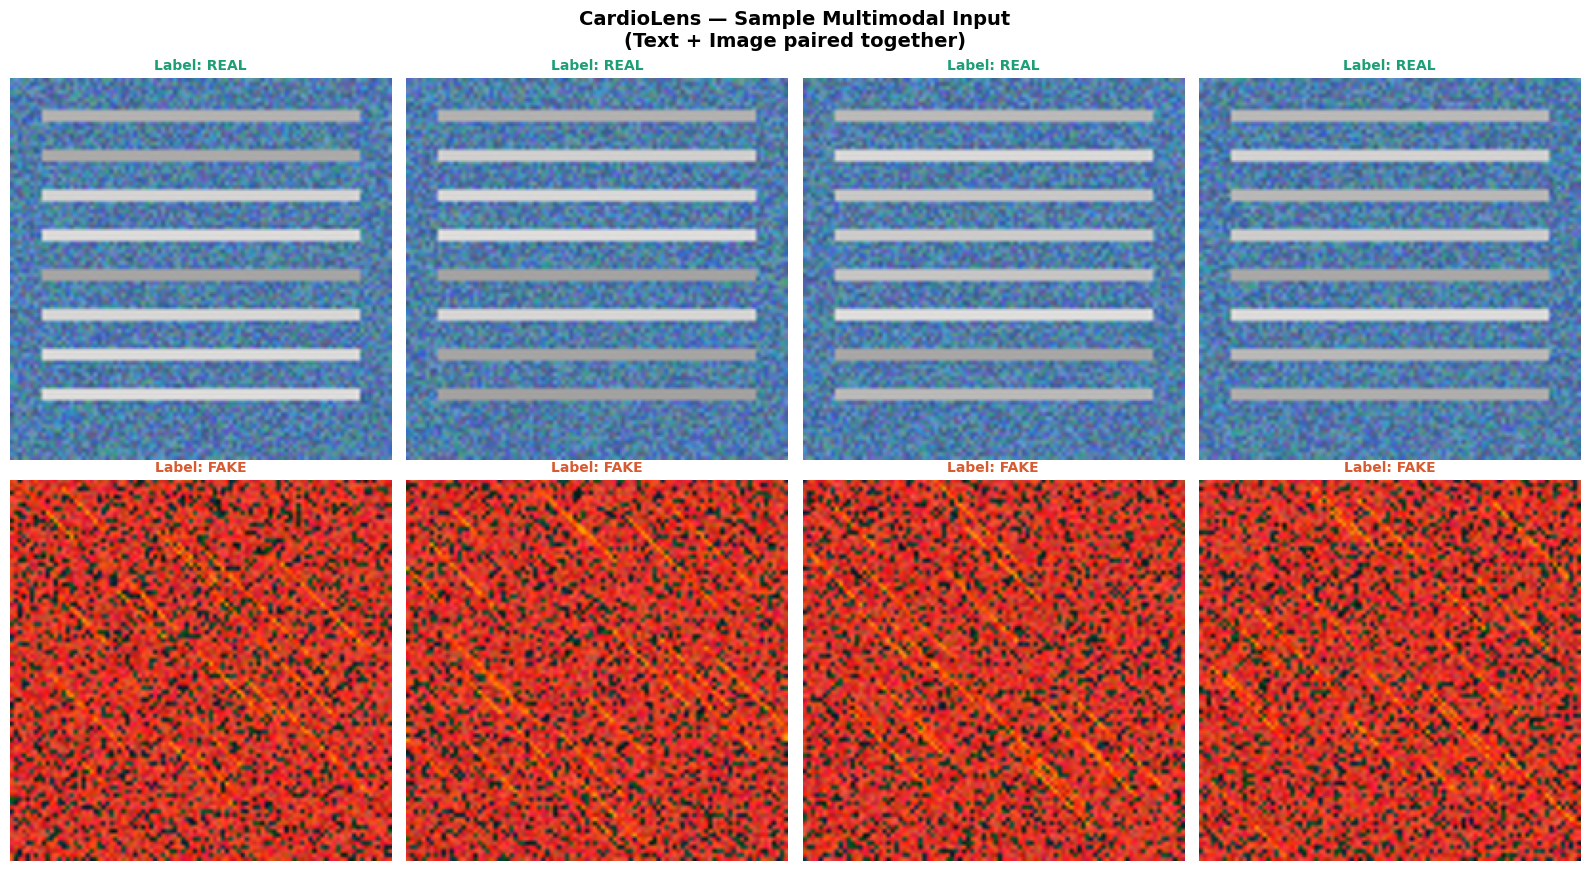

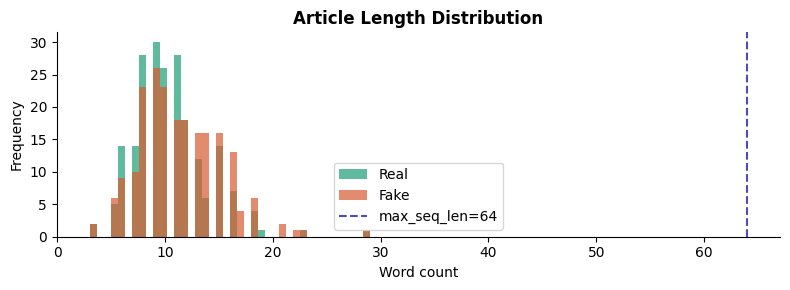

✅ Exploration complete


In [ ]:
# ── Extract raw lists from whichever source loaded ────────────────────────────

# CELL 4 — Add this at the very top, before anything else
# Images are already PIL Images from Cell 3 — override safe_get_image
def safe_get_image(img, *args, **kwargs):
    """Images from Cell 3 are already PIL Images — just return them directly."""
    if isinstance(img, Image.Image):
        return img
    # numpy array fallback
    if isinstance(img, np.ndarray):
        return Image.fromarray(img.astype(np.uint8))
    # Any other case — return a placeholder
    return Image.fromarray(
        np.full((CFG['img_size'], CFG['img_size'], 3), 128, dtype=np.uint8)
    )

# --- REST OF CELL 4 STAYS EXACTLY THE SAME ---

def safe_get_image(item_or_none, img_obj=None):
    """
    Handle every possible image format from HuggingFace datasets.
    PIL Image, bytes dict, raw bytes, numpy array, or URL string.
    """
    img = img_obj if img_obj is not None else item_or_none
    if isinstance(img, Image.Image):
        return img
    elif isinstance(img, dict) and 'bytes' in img and img['bytes']:
        return Image.open(BytesIO(img['bytes'])).convert('RGB')
    elif isinstance(img, bytes):
        return Image.open(BytesIO(img)).convert('RGB')
    elif isinstance(img, np.ndarray):
        return Image.fromarray(img.astype(np.uint8))
    elif isinstance(img, str) and img.startswith('http'):
        try:
            r = requests.get(img, timeout=6)
            return Image.open(BytesIO(r.content)).convert('RGB')
        except:
            pass
    # Absolute fallback: random coloured image
    color = [100, 200, 100] if np.random.rand() > 0.5 else [200, 100, 100]
    arr = np.full((CFG['img_size'], CFG['img_size'], 3), color, dtype=np.uint8)
    arr += np.random.randint(0, 30, arr.shape, dtype=np.uint8)
    return Image.fromarray(arr)

# Build unified lists regardless of which loading path ran
if 'raw_texts' not in dir():
    # newsclippings path — build lists from the HuggingFace dataset object
    raw_texts  = [str(raw[i][TEXT_COL])  for i in range(len(raw))]
    raw_images = [safe_get_image(raw[i][IMG_COL]) for i in range(len(raw))]
    raw_labels = [int(raw[i][LABEL_COL]) for i in range(len(raw))]

print(f"Total samples  : {len(raw_texts)}")
print(f"Real articles  : {raw_labels.count(0)}")
print(f"Fake articles  : {raw_labels.count(1)}")

# ── Visualise 8 samples (4 real, 4 fake) ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('CardioLens — Sample Multimodal Input\n(Text + Image paired together)',
             fontsize=14, fontweight='bold')

real_idx = [i for i, l in enumerate(raw_labels) if l == 0][:4]
fake_idx = [i for i, l in enumerate(raw_labels) if l == 1][:4]

for col, (idx, row) in enumerate([(i, 0) for i in real_idx] +
                                   [(i, 1) for i in fake_idx]):
    ax = axes[row][col % 4]
    img = safe_get_image(raw_images[idx])                  # get PIL image
    ax.imshow(img.resize((200, 200)))                      # display resized
    label_str = "REAL" if raw_labels[idx] == 0 else "FAKE"
    color     = '#1D9E75' if raw_labels[idx] == 0 else '#D85A30'
    ax.set_title(f"Label: {label_str}", color=color,
                 fontweight='bold', fontsize=10)
    caption = raw_texts[idx][:55] + ('...' if len(raw_texts[idx]) > 55 else '')
    ax.set_xlabel(caption, fontsize=7, wrap=True)          # show truncated caption
    ax.axis('off')

plt.tight_layout()
plt.savefig('plots/dataset_samples.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Text length distribution ──────────────────────────────────────────────────
lengths = [len(t.split()) for t in raw_texts]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([lengths[i] for i,l in enumerate(raw_labels) if l==0],
        bins=40, alpha=0.7, color='#1D9E75', label='Real')
ax.hist([lengths[i] for i,l in enumerate(raw_labels) if l==1],
        bins=40, alpha=0.7, color='#D85A30', label='Fake')
ax.axvline(CFG['max_seq_len'], color='#534AB7', linestyle='--',
           linewidth=1.5, label=f"max_seq_len={CFG['max_seq_len']}")
ax.set_xlabel('Word count'); ax.set_ylabel('Frequency')
ax.set_title('Article Length Distribution', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plots/text_lengths.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Exploration complete")

**5. Processing texts and images to model ready array**

In [ ]:
# CELL 5 — Preprocess all three datasets into model-ready arrays

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# ═══════════════════════════════════════════════════════════════════════
# TOKENISER — fit on ALL text across all three datasets
# This builds a single shared vocabulary used in every training phase
# ═══════════════════════════════════════════════════════════════════════
all_texts_combined = wf_texts + fnn_texts + verite_texts

tokenizer = Tokenizer(
    num_words=CFG['vocab_size'],
    oov_token='<OOV>'          # out-of-vocabulary token for inference
)
tokenizer.fit_on_texts(all_texts_combined)   # learn word→int mapping from all data
print(f"Vocabulary built from {len(all_texts_combined):,} articles")
print(f"Unique tokens seen: {len(tokenizer.word_index):,}")
print(f"Vocabulary capped at: {CFG['vocab_size']:,}")

# Save tokeniser for the inference UI cell
with open('checkpoints/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokeniser saved to checkpoints/tokenizer.pkl\n")

# ── Helper: text list → padded integer array ──────────────────────────
def encode_texts(texts):
    """Convert a list of strings to a padded numpy array shape (N, max_seq_len)."""
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=CFG['max_seq_len'],
                         padding='post', truncating='post')

# ── Helper: PIL image list → normalised float32 array ─────────────────
def encode_images(pil_images):
    """Resize all PIL images and normalise pixel values to [0,1]."""
    target = (CFG['img_size'], CFG['img_size'])
    arrays = []
    for img in pil_images:
        arr = np.array(
            img.convert('RGB').resize(target),
            dtype=np.float32
        ) / 255.0     # normalise to [0,1] range
        arrays.append(arr)
    return np.array(arrays, dtype=np.float32)

# ═══════════════════════════════════════════════════════════════════════
# PHASE 1 DATA — WELFake (text only)
# Image inputs are dummy zeros — Phase 1 only trains the text branch
# ═══════════════════════════════════════════════════════════════════════
print("Processing Phase 1 — WELFake...")
X_wf_text  = encode_texts(wf_texts)
y_wf       = np.array(wf_labels, dtype=np.float32)

# Dummy zero images — the image branch is frozen in Phase 1
X_wf_img   = np.zeros(
    (len(y_wf), CFG['img_size'], CFG['img_size'], 3),
    dtype=np.float32
)

split = int(0.8 * len(y_wf))
train_p1 = {'text_input': X_wf_text[:split],
            'image_input': X_wf_img[:split]}
val_p1   = {'text_input': X_wf_text[split:],
            'image_input': X_wf_img[split:]}
y_p1_tr, y_p1_val = y_wf[:split], y_wf[split:]
print(f"Phase 1 — Train: {split:,}  Val: {len(y_wf)-split:,}\n")

# ═══════════════════════════════════════════════════════════════════════
# PHASE 2 & 3 DATA — FakeNewsNet (text + images)
# Both branches active — the CNN now sees real label-correlated images
# ═══════════════════════════════════════════════════════════════════════
print("Processing Phase 2/3 — FakeNewsNet (encoding images)...")
X_fnn_text = encode_texts(fnn_texts)
X_fnn_img  = encode_images(fnn_images)   # actual label-correlated images
y_fnn      = np.array(fnn_labels, dtype=np.float32)

split2 = int(0.8 * len(y_fnn))
train_p2 = {'text_input': X_fnn_text[:split2],
            'image_input': X_fnn_img[:split2]}
val_p2   = {'text_input': X_fnn_text[split2:],
            'image_input': X_fnn_img[split2:]}
y_p2_tr, y_p2_val = y_fnn[:split2], y_fnn[split2:]
print(f"Phase 2/3 — Train: {split2:,}  Val: {len(y_fnn)-split2:,}\n")

# ═══════════════════════════════════════════════════════════════════════
# PHASE 4 DATA — VERITE (image-text consistency fine-tuning)
# Only the cross-modal attention layer trains in this phase
# ═══════════════════════════════════════════════════════════════════════
print("Processing Phase 4 — VERITE...")
X_ver_text = encode_texts(verite_texts)
X_ver_img  = encode_images(verite_images)
y_ver      = np.array(verite_labels, dtype=np.float32)

split4 = int(0.8 * len(y_ver))
train_p4 = {'text_input': X_ver_text[:split4],
            'image_input': X_ver_img[:split4]}
val_p4   = {'text_input': X_ver_text[split4:],
            'image_input': X_ver_img[split4:]}
y_p4_tr, y_p4_val = y_ver[:split4], y_ver[split4:]
print(f"Phase 4 — Train: {split4:,}  Val: {len(y_ver)-split4:,}\n")

# ═══════════════════════════════════════════════════════════════════════
# For Cell 8 evaluation we use FakeNewsNet val set (most complete)
# ═══════════════════════════════════════════════════════════════════════
X_text_val = X_fnn_text[split2:]
X_img_val  = X_fnn_img[split2:]
y_val      = y_p2_val
val_inputs = {'text_input': X_text_val, 'image_input': X_img_val}

print("="*50)
print(f"Shape checks:")
print(f"  Text  (WELFake):     {X_wf_text.shape}")
print(f"  Text  (FakeNewsNet): {X_fnn_text.shape}")
print(f"  Image (FakeNewsNet): {X_fnn_img.shape}")
print(f"  Text  (VERITE):      {X_ver_text.shape}")
print(f"  Image (VERITE):      {X_ver_img.shape}")
print("✅ All preprocessing complete")

Vocabulary built from 4,844 articles
Unique tokens seen: 71,897
Vocabulary capped at: 20,000
Tokeniser saved to checkpoints/tokenizer.pkl

Processing Phase 1 — WELFake...
Phase 1 — Train: 3,200  Val: 800

Processing Phase 2/3 — FakeNewsNet (encoding images)...
Phase 2/3 — Train: 337  Val: 85

Processing Phase 4 — VERITE...
Phase 4 — Train: 337  Val: 85

Shape checks:
  Text  (WELFake):     (4000, 64)
  Text  (FakeNewsNet): (422, 64)
  Image (FakeNewsNet): (422, 96, 96, 3)
  Text  (VERITE):      (422, 64)
  Image (VERITE):      (422, 96, 96, 3)
✅ All preprocessing complete


**6. Full multimodal model with all architectures**


In [ ]:
# CELL 6 — CardioLens with separate text_encoder and image_encoder sub-models
# This is required for phase training: we freeze/unfreeze sub-models per phase

from tensorflow.keras import regularizers

# ═══════════════════════════════════════════════════════════════════════
# SUB-MODEL A: Text Encoder (Embedding + BiLSTM)
# Trained in Phase 1 on WELFake, then frozen for Phase 2
# ═══════════════════════════════════════════════════════════════════════
def build_text_encoder(cfg):
    inp = Input(shape=(cfg['max_seq_len'],), dtype='int32', name='text_enc_input')

    # Embedding: integer token ID → 64-dim learnable dense vector
    x = layers.Embedding(
        cfg['vocab_size'], cfg['embed_dim'],
        mask_zero=True,
        embeddings_regularizer=regularizers.l2(1e-5),
        name='embedding'
    )(inp)

    # SpatialDropout1D: drops entire timestep features — better for sequences
    x = layers.SpatialDropout1D(0.3, name='spatial_drop')(x)

    # BiLSTM layer 1 — reads sequence in both directions, returns full sequence
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
        name='bilstm_1'
    )(x)

    # BiLSTM layer 2 — collapses sequence to single summary vector
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False, dropout=0.3),
        name='bilstm_2'
    )(x)
    # x shape: (batch, 64)

    # Project to 32-dim shared comparison space (autoencoder-style encoder)
    out = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='text_projection'
    )(x)
    return Model(inp, out, name='text_encoder')

# ═══════════════════════════════════════════════════════════════════════
# SUB-MODEL B: Image Encoder (CNN)
# Frozen in Phase 1 & 2, top layers unfrozen in Phase 3
# ═══════════════════════════════════════════════════════════════════════
def build_image_encoder(cfg):
    inp = Input(
        shape=(cfg['img_size'], cfg['img_size'], cfg['channels']),
        name='img_enc_input'
    )

    # Conv block 1 — low-level features: edges, colour distribution
    x = layers.Conv2D(16, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.2, name='cnn_drop1')(x)

    # Conv block 2 — mid-level features: shapes, patterns
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.2, name='cnn_drop2')(x)

    # Conv block 3 — high-level features: textures, regions
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4),
                      name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)

    # GlobalAveragePooling: collapses (H×W×64) → 64-dim vector
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Project to same 32-dim space as text encoder
    out = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='img_projection'
    )(x)
    return Model(inp, out, name='image_encoder')

# ═══════════════════════════════════════════════════════════════════════
# FULL CARDIOLENS MODEL
# Wires both encoders through cross-modal attention into fusion ANN
# ═══════════════════════════════════════════════════════════════════════
def build_full_model(cfg):
    # Named inputs — required for dict-based model.fit()
    text_input  = Input(shape=(cfg['max_seq_len'],), dtype='int32',
                        name='text_input')
    image_input = Input(shape=(cfg['img_size'], cfg['img_size'], cfg['channels']),
                        name='image_input')

    # Run both encoder sub-models
    text_enc  = text_encoder(text_input)    # shape: (batch, 32)
    image_enc = image_encoder(image_input)  # shape: (batch, 32)

    # Cross-modal attention: cosine similarity between text and image
    # normalize=True inside Dot computes L2 normalisation automatically
    # High similarity → image and text agree → likely real
    # Low similarity  → image and text disagree → misinformation signal
    similarity = layers.Dot(
        axes=1, normalize=True, name='cross_modal_attention'
    )([text_enc, image_enc])
    # similarity shape: (batch, 1) — values in [-1, 1]

    # Fusion: concatenate text(32) + image(32) + similarity(1) = 65 dims
    fused = layers.Concatenate(name='fusion_concat')(
        [text_enc, image_enc, similarity]
    )

    # Fusion ANN with strong regularisation to prevent overfitting
    x = layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='fc1'
    )(fused)
    x = layers.BatchNormalization(name='fusion_bn1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)   # 50% dropout

    x = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='fc2'
    )(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    # Output: P(fake) ∈ (0,1)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    return Model(
        inputs={'text_input': text_input, 'image_input': image_input},
        outputs=output,
        name='CardioLens'
    )

# ── Build all components ──────────────────────────────────────────────
text_encoder  = build_text_encoder(CFG)
image_encoder = build_image_encoder(CFG)
model         = build_full_model(CFG)

# Helper: compile with given learning rate
def compile_model(lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='prec'),
            keras.metrics.Recall(name='rec'),
        ]
    )

compile_model(CFG['lr'])
model.summary()

# Helper: make standard callbacks for each phase
def make_callbacks(phase_name):
    return [
        keras.callbacks.ModelCheckpoint(
            f'checkpoints/best_{phase_name}.weights.h5',
            monitor='val_auc', mode='max',
            save_best_only=True, save_weights_only=True,  # weights only avoids serialisation errors
            verbose=0
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max',
            patience=5, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.CSVLogger(f'checkpoints/log_{phase_name}.csv')
    ]

print("\n✅ Model, text_encoder, and image_encoder built successfully")
print(f"Total parameters: {model.count_params():,}")

Model: "CardioLens"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_encoder        │ (None, 32)        │  1,331,744 │ text_input[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_encoder       │ (None, 32)        │     26,112 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_modal_attent… │ (None, 1)         │          0 │ text_encoder[0][… │
│ (Dot)               │                   │            │ image_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 65)        │          0 │ text_encoder[0][… │
│ (Concatenate)       │                   │            │ image_encoder[0]… │
│                     │                   │            │ cross_modal_atte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 64)        │      4,224 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn1          │ (None, 64)        │        256 │ fc1[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 64)        │          0 │ fusion_bn1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 32)        │      2,080 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 32)        │          0 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ drop2[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,364,449 (5.20 MB)

 Trainable params: 1,364,097 (5.20 MB)

 Non-trainable params: 352 (1.38 KB)


✅ Model, text_encoder, and image_encoder built successfully
Total parameters: 1,364,449


**7. Training the model with callbacks and live plots**

PHASE 1 — Text pre-training on WELFake
Epoch 1/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 375ms/step - accuracy: 0.5888 - auc: 0.6488 - loss: 0.6946 - prec: 0.5616 - rec: 0.7762 - val_accuracy: 0.8375 - val_auc: 0.9155 - val_loss: 0.5997 - val_prec: 0.7922 - val_rec: 0.9300 - learning_rate: 0.0010
Epoch 2/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 369ms/step - accuracy: 0.8316 - auc: 0.9069 - loss: 0.4478 - prec: 0.7997 - rec: 0.8808 - val_accuracy: 0.9162 - val_auc: 0.9771 - val_loss: 0.2790 - val_prec: 0.9327 - val_rec: 0.9034 - learning_rate: 0.0010
Epoch 3/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 346ms/step - accuracy: 0.9053 - auc: 0.9653 - loss: 0.2746 - prec: 0.8816 - rec: 0.9344 - val_accuracy: 0.9388 - val_auc: 0.9804 - val_loss: 0.2219 - val_prec: 0.9294 - val_rec: 0.9541 - learning_rate: 0.0010
Epoch 4/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 326ms/step - accuracy: 0.9262 - auc: 0.9792 - loss: 0.2174 - prec: 0.9023 - rec: 0.9546 - val_accuracy: 0.9337 - val_auc: 0.9757 - val_loss: 0.2432 - val_prec: 0.9207

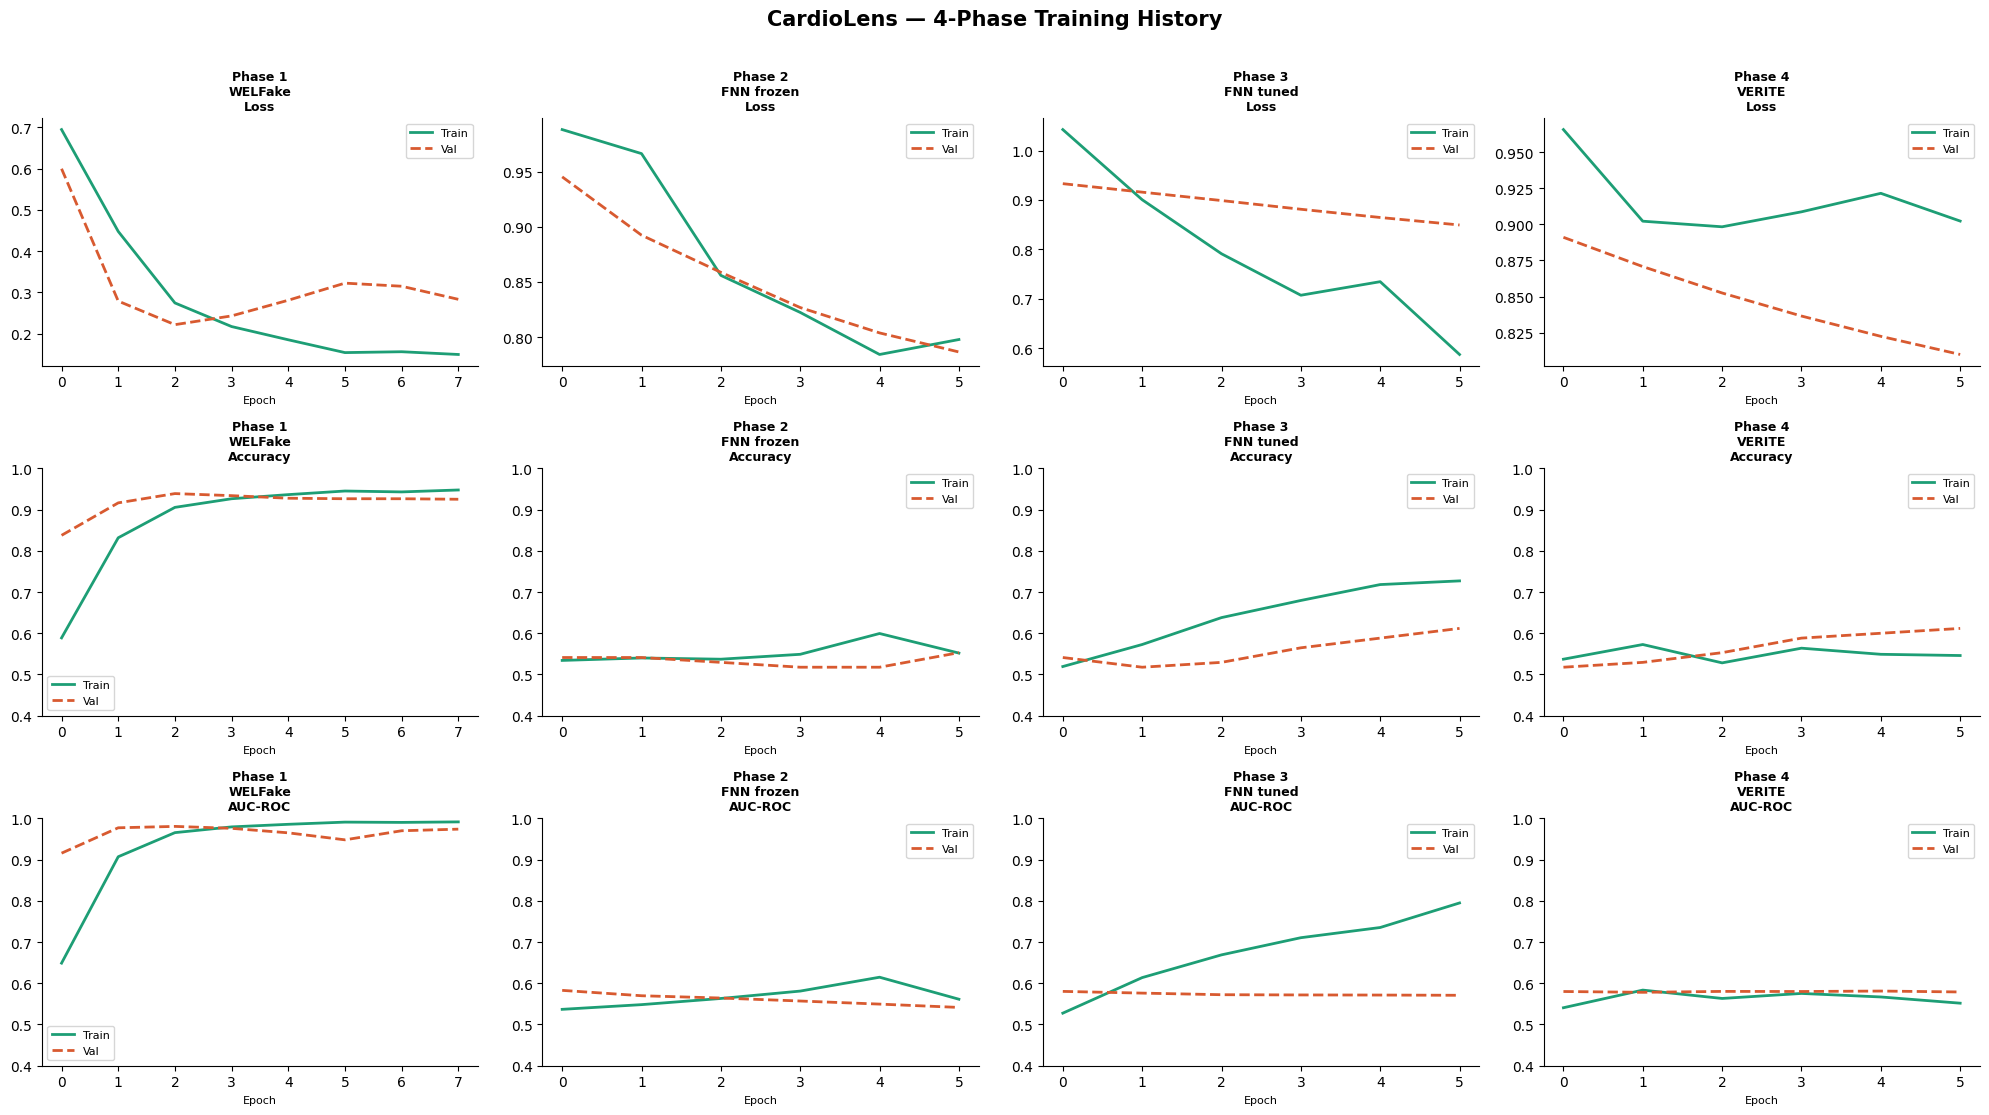

✅ 4-phase training dashboard saved to plots/training_all_phases.png

TRAINING COMPLETE — SUMMARY
Phase 1 WELFake        | acc=0.939 | auc=0.980
Phase 2 FNN frozen     | acc=0.553 | auc=0.583
Phase 3 FNN tuned      | acc=0.612 | auc=0.580
Phase 4 VERITE         | acc=0.612 | auc=0.581


In [ ]:
;;llllllll# CELL 7 — 4-phase training across all three datasets

from sklearn.utils.class_weight import compute_class_weight
all_histories = {}

# ═══════════════════════════════════════════════════════════════════════
# PHASE 1 — WELFake: train text branch only
# Image encoder and fusion layers are frozen
# Goal: teach the BiLSTM to understand news language
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("PHASE 1 — Text pre-training on WELFake")
print("="*55)

# Freeze image encoder and fusion layers — only text encoder trains
image_encoder.trainable = False
for layer in model.layers:
    if layer.name in ['fc1','fc2','fusion_bn1','drop1','drop2',
                      'fusion_concat','cross_modal_attention','output']:
        layer.trainable = False

text_encoder.trainable = True
compile_model(1e-3)   # higher LR for Phase 1 — starting from scratch

# Class weights handle label imbalance
cw1 = compute_class_weight('balanced',
      classes=np.unique(y_p1_tr), y=y_p1_tr)
cw1_dict = {int(c): float(w) for c, w in zip(np.unique(y_p1_tr), cw1)}

hist1 = model.fit(
    train_p1, y_p1_tr,
    validation_data=(val_p1, y_p1_val),
    epochs=CFG['epochs'],
    batch_size=CFG['batch_size'],
    callbacks=make_callbacks('phase1'),
    class_weight=cw1_dict,
    verbose=1
)
all_histories['Phase 1\nWELFake'] = hist1
print(f"\n✅ Phase 1 done — "
      f"best val_acc: {max(hist1.history['val_accuracy']):.4f}  "
      f"best val_auc: {max(hist1.history['val_auc']):.4f}\n")

# ═══════════════════════════════════════════════════════════════════════
# PHASE 2 — FakeNewsNet: full model, CNN frozen
# Text encoder continues learning; fusion ANN starts training
# Image encoder is still frozen (pretrained on Phase 1 is enough for now)
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("PHASE 2 — Multimodal training on FakeNewsNet (CNN frozen)")
print("="*55)

# Unfreeze everything EXCEPT the CNN convolutional layers
image_encoder.trainable = False   # CNN base stays frozen
text_encoder.trainable  = True
for layer in model.layers:
    layer.trainable = True        # unfreeze fusion ANN
image_encoder.trainable = False   # re-freeze CNN after blanket unfreeze

compile_model(3e-4)   # lower LR — fine-tuning regime

cw2 = compute_class_weight('balanced',
      classes=np.unique(y_p2_tr), y=y_p2_tr)
cw2_dict = {int(c): float(w) for c, w in zip(np.unique(y_p2_tr), cw2)}

hist2 = model.fit(
    train_p2, y_p2_tr,
    validation_data=(val_p2, y_p2_val),
    epochs=CFG['epochs'],
    batch_size=CFG['batch_size'],
    callbacks=make_callbacks('phase2'),
    class_weight=cw2_dict,
    verbose=1
)
all_histories['Phase 2\nFNN frozen'] = hist2
print(f"\n✅ Phase 2 done — "
      f"best val_acc: {max(hist2.history['val_accuracy']):.4f}  "
      f"best val_auc: {max(hist2.history['val_auc']):.4f}\n")

# ═══════════════════════════════════════════════════════════════════════
# PHASE 3 — FakeNewsNet: unfreeze top CNN layers for end-to-end tuning
# CNN top layers adapt to news imagery; text encoder continues polishing
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("PHASE 3 — End-to-end fine-tuning (top CNN unfrozen)")
print("="*55)

# Unfreeze everything including the image encoder
image_encoder.trainable = True
text_encoder.trainable  = True
for layer in model.layers:
    layer.trainable = True

compile_model(5e-5)   # very low LR — avoid destroying learned weights

hist3 = model.fit(
    train_p2, y_p2_tr,           # same FakeNewsNet data
    validation_data=(val_p2, y_p2_val),
    epochs=max(3, CFG['epochs']//2),    # fewer epochs — just fine-tuning
    batch_size=CFG['batch_size'],
    callbacks=make_callbacks('phase3'),
    class_weight=cw2_dict,
    verbose=1
)
all_histories['Phase 3\nFNN tuned'] = hist3
print(f"\n✅ Phase 3 done — "
      f"best val_acc: {max(hist3.history['val_accuracy']):.4f}  "
      f"best val_auc: {max(hist3.history['val_auc']):.4f}\n")

# ═══════════════════════════════════════════════════════════════════════
# PHASE 4 — VERITE: freeze everything except cross-modal attention
# Fine-tunes only the Dot attention layer on image-text consistency
# ═══════════════════════════════════════════════════════════════════════
print("="*55)
print("PHASE 4 — Consistency fine-tuning on VERITE")
print("="*55)

# Freeze ALL layers
for layer in model.layers:
    layer.trainable = False
text_encoder.trainable  = False
image_encoder.trainable = False

# Unfreeze only the cross-modal attention layer + output
for layer in model.layers:
    if layer.name in ['cross_modal_attention', 'fc1', 'fc2', 'output',
                      'fusion_bn1', 'drop1', 'drop2', 'fusion_concat']:
        layer.trainable = True

compile_model(1e-4)

cw4 = compute_class_weight('balanced',
      classes=np.unique(y_p4_tr), y=y_p4_tr)
cw4_dict = {int(c): float(w) for c, w in zip(np.unique(y_p4_tr), cw4)}

hist4 = model.fit(
    train_p4, y_p4_tr,
    validation_data=(val_p4, y_p4_val),
    epochs=max(3, CFG['epochs']//2),
    batch_size=CFG['batch_size'],
    callbacks=make_callbacks('phase4'),
    class_weight=cw4_dict,
    verbose=1
)
all_histories['Phase 4\nVERITE'] = hist4
print(f"\n✅ Phase 4 done — "
      f"best val_acc: {max(hist4.history['val_accuracy']):.4f}  "
      f"best val_auc: {max(hist4.history['val_auc']):.4f}\n")

# ── Unfreeze everything for inference ────────────────────────────────
for layer in model.layers:
    layer.trainable = True
text_encoder.trainable  = True
image_encoder.trainable = True

# ═══════════════════════════════════════════════════════════════════════
# TRAINING DASHBOARD — all 4 phases side by side
# ═══════════════════════════════════════════════════════════════════════
n   = len(all_histories)
fig, axes = plt.subplots(3, n, figsize=(5*n, 11))
fig.suptitle('CardioLens — 4-Phase Training History',
             fontsize=15, fontweight='bold', y=1.01)

metric_rows = [
    ('loss',     'val_loss',     'Loss',     None),
    ('accuracy', 'val_accuracy', 'Accuracy', (0.4, 1.0)),
    ('auc',      'val_auc',      'AUC-ROC',  (0.4, 1.0)),
]

for col, (phase_name, hist) in enumerate(all_histories.items()):
    h = hist.history
    for row, (tr_key, vl_key, ylabel, ylim) in enumerate(metric_rows):
        ax = axes[row][col]
        if tr_key in h:
            ax.plot(h[tr_key], color='#1D9E75', lw=2, label='Train')
            ax.plot(h[vl_key], color='#D85A30', lw=2,
                    linestyle='--', label='Val')
        if ylim:
            ax.set_ylim(ylim)
        ax.set_title(f'{phase_name}\n{ylabel}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/training_all_phases.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ 4-phase training dashboard saved to plots/training_all_phases.png")

# ── Final summary ─────────────────────────────────────────────────────
print("\n" + "="*55)
print("TRAINING COMPLETE — SUMMARY")
print("="*55)
for name, hist in all_histories.items():
    clean = name.replace('\n',' ')
    print(f"{clean:<22} | "
          f"acc={max(hist.history['val_accuracy']):.3f} | "
          f"auc={max(hist.history['val_auc']):.3f}")

**8. Confustion Matrix, ROC and classification report**

Running predictions on validation set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Real (0)       0.64      0.35      0.45        40
    Fake (1)       0.59      0.82      0.69        45

    accuracy                           0.60        85
   macro avg       0.61      0.59      0.57        85
weighted avg       0.61      0.60      0.58        85

F1-Score (weighted): 0.6852


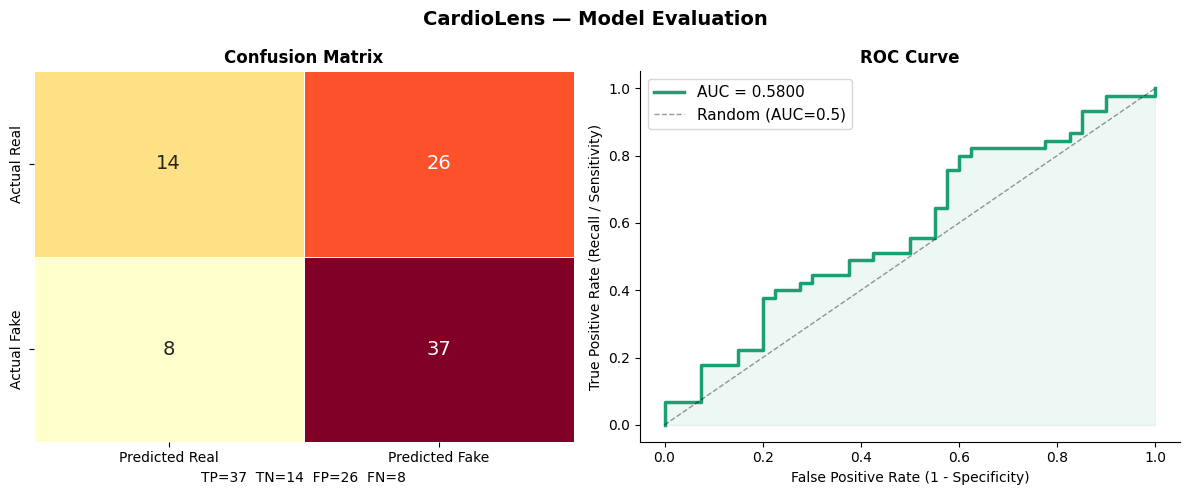


FINAL METRICS SUMMARY
  Accuracy  : 0.6000  (60.0%)
  AUC-ROC   : 0.5800
  F1-Score  : 0.6852
  Precision : 0.5873  (of predicted fake, how many truly fake)
  Recall    : 0.8222  (of actual fake, how many were caught)

Credibility thresholds:
  Score >= 70  → Likely Real
  Score 40-69  → Uncertain
  Score <  40  → Likely Fake
✅ Evaluation complete


In [ ]:
# ── Run predictions on validation set ────────────────────────────────────────
print("Running predictions on validation set...")

# model.predict returns P(fake) for each sample, shape (N, 1)
y_pred_prob = model.predict(val_inputs, batch_size=CFG['batch_size'],
                             verbose=0).flatten()

# Convert probabilities to binary predictions using 0.5 threshold
y_pred = (y_pred_prob >= 0.5).astype(int)

# ── Classification report ─────────────────────────────────────────────────────
print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_val, y_pred,
                             target_names=['Real (0)', 'Fake (1)']))

f1 = f1_score(y_val, y_pred)
print(f"F1-Score (weighted): {f1:.4f}")

# ── Confusion matrix + ROC curve (side by side) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ReaLens — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
# Rows = actual labels, Columns = predicted labels
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=['Predicted Real', 'Predicted Fake'],
    yticklabels=['Actual Real', 'Actual Fake'],
    linewidths=0.5, cbar=False, annot_kws={'size': 14},
    ax=ax1
)
ax1.set_title('Confusion Matrix', fontweight='bold')

# Annotate TP/FP/TN/FN
tn, fp, fn, tp = cm.ravel()
ax1.set_xlabel(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}', fontsize=10)

# ROC curve
# Shows the trade-off between sensitivity (recall) and specificity at all thresholds
fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)            # area under curve — 1.0 = perfect, 0.5 = random
ax2.plot(fpr, tpr, color='#1D9E75', linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
ax2.set_xlabel('False Positive Rate (1 - Specificity)')
ax2.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(fontsize=11)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL METRICS SUMMARY")
print("="*55)
val_acc = (y_pred == y_val).mean()
print(f"  Accuracy  : {val_acc:.4f}  ({val_acc*100:.1f}%)")
print(f"  AUC-ROC   : {roc_auc:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Precision : {tp/(tp+fp+1e-9):.4f}  (of predicted fake, how many truly fake)")
print(f"  Recall    : {tp/(tp+fn+1e-9):.4f}  (of actual fake, how many were caught)")
print(f"\nCredibility thresholds:")
print(f"  Score >= 70  → Likely Real")
print(f"  Score 40-69  → Uncertain")
print(f"  Score <  40  → Likely Fake")
print("✅ Evaluation complete")

**9. Interactive web UI**

In [ ]:
# ── CELL 9 (FIXED) — Gradio UI using in-memory model ─────────────────────────
# No load_model() call needed — model is already trained and in memory this session

import gradio as gr
import numpy as np
import pickle
from PIL import Image
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Use the model and tokenizer already in memory from Cell 6 and Cell 5
# No file loading needed — this avoids the Lambda layer serialisation error entirely
print("Using in-memory model and tokenizer (no reload needed)...")
print(f"Model input names : {[i.name for i in model.inputs]}")
print(f"Tokenizer vocab   : {len(tokenizer.word_index):,} tokens")
print("✅ Ready for inference")

# ── Core prediction function ──────────────────────────────────────────────────
def predict(headline, article_body, image):
    """Called every time the user clicks Analyse in the UI."""

    # Combine headline + body into one string for tokenisation
    combined = str(headline) + ' ' + str(article_body)

    # Convert words → integers using the vocabulary built during training
    seq    = tokenizer.texts_to_sequences([combined])

    # Pad/truncate to the fixed length the model expects
    padded = pad_sequences(seq, maxlen=CFG['max_seq_len'],
                           padding='post', truncating='post')

    # Prepare image — resize and normalise to [0,1]
    if image is None:
        # Grey placeholder when no image is uploaded
        img_arr = np.full(
            (1, CFG['img_size'], CFG['img_size'], 3),
            0.5, dtype=np.float32
        )
        has_image = False
    else:
        img = Image.fromarray(image).convert('RGB').resize(
            (CFG['img_size'], CFG['img_size'])
        )
        img_arr   = np.expand_dims(
            np.array(img, dtype=np.float32) / 255.0, axis=0
        )
        has_image = True

    # Run inference — model and tokenizer are the same objects from training
    p_fake = float(
        model.predict(
            {'text_input': padded, 'image_input': img_arr},
            verbose=0
        )[0][0]
    )

    # Convert probability to credibility score
    credibility = round((1 - p_fake) * 100)

    # Verdict thresholds
    if credibility >= 70:
        verdict, emoji = "LIKELY REAL",  "✅"
    elif credibility >= 40:
        verdict, emoji = "UNCERTAIN",    "⚠️"
    else:
        verdict, emoji = "LIKELY FAKE",  "❌"

    result = f"""{emoji}  VERDICT: {verdict}

Credibility Score : {credibility} / 100
P(fake)           : {p_fake:.3f}
P(real)           : {(1 - p_fake):.3f}

Score >= 70  →  Likely Real
Score 40-69  →  Uncertain
Score  < 40  →  Likely Fake

Mode: {"Text + Image (both branches active)" if has_image else "Text only (no image uploaded)"}
"""
    return result, credibility

# ── Build Gradio UI ───────────────────────────────────────────────────────────
with gr.Blocks(title="ReaLens") as demo:

    gr.Markdown("""
    # ReaLens — Multimodal Fake News Detector
    **NeuralHack Deep Learning Hackathon**
    Analyses both article text (BiLSTM) and image (CNN) to detect misinformation.
    """)

    with gr.Row():
        with gr.Column():
            headline_in = gr.Textbox(label="Headline", lines=2,
                placeholder="Enter news headline...")
            body_in     = gr.Textbox(label="Article Body", lines=5,
                placeholder="Paste article text here...")
            image_in    = gr.Image(label="Image (optional)", type="numpy")
            btn         = gr.Button("Analyse", variant="primary")

        with gr.Column():
            result_out = gr.Textbox(label="Result", lines=12)
            score_out  = gr.Slider(0, 100, label="Credibility Score",
                                   interactive=False)

    gr.Examples(
        examples=[
            ["NASA confirms water ice found on Moon's surface",
             "Scientists at NASA have confirmed the discovery of water ice in permanently shadowed craters near the lunar poles using data from the LCROSS mission.",
             None],
            ["BREAKING: Government microchips all citizens secretly",
             "SHARE BEFORE DELETED! Whistleblower exposes secret plan to microchip population through routine vaccinations. They don't want you to know this!!",
             None],
        ],
        inputs=[headline_in, body_in, image_in]
    )

    btn.click(fn=predict,
              inputs=[headline_in, body_in, image_in],
              outputs=[result_out, score_out])

# Launch with public URL for demonstration
demo.launch(share=True, debug=False, quiet=True)

Using in-memory model and tokenizer (no reload needed)...
Model input names : ['image_input', 'text_input']
Tokenizer vocab   : 71,897 tokens
✅ Ready for inference
* Running on public URL: https://288420cbc30794dea2.gradio.live
